# Notebook 06 — Detailed Multi-Layer Body Internal Compression + Injury Prediction

Author: Stellars Henson<br>
Approach: model the body as a 5-DOF anatomical chain capturing **skin → scapula → ribcage → internal organs → spine + bulk**, with viscoelastic linkages calibrated to literature.  When the body impacts the door, the door-side contact force is limited by panel compliance to ~5 kN (per notebook 04/05 FEM-coupled simulation), but the **body's kinetic energy must still be absorbed internally** — via compression of soft tissue layers around the rigid skeletal elements.  This internal compression is what drives injury (rib fracture, pulmonary contusion), independent of door-side peak force.

## Why this matters for the incident analysis

The doc's 18 kN rigid-wall prediction is an EXTERNAL force estimate.  The internal injury picture is more nuanced:

- Door is compliant (FEM panel deflects under load) → external force at contact reduced to ~5 kN
- Body's full 361 J of kinetic energy still has to go somewhere
- Most of it goes into **internal compression**: trapezius muscle, scapular bone deflection, rib cage, intercostal spaces, internal organs
- Peak INTERNAL compression forces between rigid body elements (scapula-rib, rib-spine) can EXCEED the external door-side force
- This is the energy path responsible for AIS 3-5 thoracic injury despite modest external contact force

## Approach

1. **5-DOF body anatomical model**:
   - m₁: posterior skin + subcutaneous tissue (1.5 kg)
   - m₂: scapular bone + deep posterior muscles (3 kg)
   - m₃: ribcage + intercostal soft tissue (10 kg)
   - m₄: internal organs (heart, lungs, mediastinum, 15 kg)
   - m₅: spine + bulk body (40 kg)
2. **Viscoelastic linkages**: k, c for each of 4 interfaces, calibrated from Lobdell 1973 / Stalnaker 1973 / Kemper 2014 with anatomical scaling factors.
3. **External contact** with door panel: Hunt-Crossley at m₁, force limited by FEM panel compliance (use literature ceiling 5 kN matching notebook 04).
4. **Internal compression tracking**: at each timestep compute the compression of each soft-tissue layer (δ_skin, δ_intercostal, δ_organ, δ_spine).
5. **Injury prediction**:
   - Rib fracture: ribcage compression exceeds 25 mm OR rib-loading force exceeds 1.6 kN per rib (Viano 1989)
   - Pulmonary contusion: organ compression / VC criterion exceeds 1.0 m/s threshold (Viano 1989)
   - Soft-tissue contusion: skin compression > 10 mm with significant strain rate
6. **Contact-area variation**: sweep 4 different contact patches (small / medium / large / point) to quantify how concentration affects injury distribution.

## Literature references

- Lobdell, T.E. et al. (1973) — thorax impact response, 3-DOF chest model parameters
- Stalnaker, R.L. (1973) — tensed/relaxed stiffness ratio 121-337%
- Viano, D.C. (1989) — thoracic AIS injury criteria, Viscous Criterion (VC)
- Cavanaugh, J.M. (1989) — thoracic trauma biomechanics, rib fracture force-deflection
- Kroell, C.K. (1971) — cadaver chest impact, force-deflection curves
- Kemper, A.R. et al. (2014) — rear-torso impact biomechanics, posterior-thorax dynamic response
- Iwamoto, M. et al. — pre-impact bracing effects, multi-DOF body models

## Outputs

- `reports/figures/06-body-anatomical-layers.png` — 5-layer body model schematic
- `reports/figures/06-internal-compressions.png` — δ(t) for each layer
- `reports/figures/06-internal-forces.png` — F(t) at each interface (skin / scapula-rib / rib-organ / organ-spine)
- `reports/figures/06-injury-summary.png` — AIS injury verdict per interface
- `reports/figures/06-contact-area-sweep.png` — comparison across 4 contact patch sizes

In [1]:
# Imports
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

from scipy.integrate import solve_ivp

from henryk_simulations.corridor import default_scenario, compute_scenario

%load_ext autoreload
%autoreload 2

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

2026-05-15 19:38:34.707 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)

## Configuration - 5-Layer Body Model

**Anatomical layers** (posterior → anterior):

| Layer | Mass (kg) | Description |
|------:|----------:|:-----------|
| m₁ | 1.5 | skin + posterior fat + superficial muscles (contact pad) |
| m₂ | 3.0 | scapula bone + deep posterior muscles (trapezius, rhomboids) |
| m₃ | 10.0 | ribcage + intercostal muscles + sternum |
| m₄ | 15.0 | internal organs (heart, lungs, mediastinum) |
| m₅ | 40.0 | spine + bulk body (lower abdomen, pelvis, legs) |

Total: 69.5 kg ≈ 70 kg target.

**Viscoelastic interfaces** (k = stiffness N/m, c = damping N·s/m):

| Interface | k (N/mm) | c (N·s/m) | Rationale |
|----------:|---------:|----------:|:----------|
| skin → scapula | 200 | 800 | Lobdell skin × tensed factor × posterior factor |
| scapula → rib | 800 | 1500 | bone-rib articulation, stiff but compliant via cartilage |
| rib → organ | 350 | 1200 | rib cage compression, key injury site (Viano AIS) |
| organ → spine | 600 | 2000 | mediastinum + paraspinal muscles to vertebrae |

In [3]:
# Lower-bound impact velocity from notebook 01 library
_scenario_result = compute_scenario(default_scenario())
LOWER_BOUND = next(r.impact for r in _scenario_result if r.impact is not None)
console.print(f"Lower-bound from notebook 01: v_impact = {LOWER_BOUND.v_impact:.4f} m/s, "
              f"KE = {LOWER_BOUND.ke_impact:.1f} J")

PARAMS = {
    "masses_kg": {
        "m1_skin": 1.5,
        "m2_scapula": 3.0,
        "m3_ribcage": 10.0,
        "m4_organ": 15.0,
        "m5_spine": 40.0,
    },
    "interfaces_stiffness_N_per_m": {
        "k12_skin":    2.0e5,    # 200 N/mm posterior skin/fat
        "k23_scapula": 8.0e5,    # 800 N/mm scapula-rib articulation
        "k34_rib":     3.5e5,    # 350 N/mm ribcage compression (injury site)
        "k45_spine":   6.0e5,    # 600 N/mm organ-spine
    },
    "interfaces_damping_Ns_per_m": {
        "c12_skin":    800,
        "c23_scapula": 1500,
        "c34_rib":     1200,
        "c45_spine":   2000,
    },
    "external": {
        # External contact: door panel compliance limits F_peak at ~5 kN per
        # notebook 04 FEM coupled simulation.  We model the door as a stiff
        # spring with damping that ramps up the body's contact force.
        "k_door_N_per_m_pow_n": 5.0e6,   # door + skin contact stiffness
        "n_contact": 1.5,
        "lambda_HC": 1.5,                  # heavy damping (body deposits KE)
        "v_impact_m_per_s": LOWER_BOUND.v_impact,
    },
    "injury_thresholds": {
        "rib_fracture_N": 1600.0,         # Viano 1989: 1.6 kN per rib AIS 2+
        "rib_compression_mm": 25.0,        # Cavanaugh 1989: AIS 3+ at 25 mm
        "organ_compression_mm": 50.0,      # severe pulmonary contusion threshold
        "VC_threshold_m_per_s": 1.0,       # Viscous Criterion AIS 4+
    },
    "integration": {
        "t_final_s": 0.3,
        "rtol": 1e-7, "atol": 1e-10, "max_step_s": 2e-5,
    },
    "paths": {"fig_dir": Path("..") / "reports" / "figures"},
}

FIG_DIR = PARAMS["paths"]["fig_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

tbl = Table(show_header=False, box=None, padding=(0, 2))
tbl.add_column("k", style="bold cyan"); tbl.add_column("v")
for section, items in PARAMS.items():
    if isinstance(items, dict):
        tbl.add_row(f"[bold magenta]{section}[/bold magenta]", "")
        for k, v in items.items():
            tbl.add_row(f"  {k}", f"[white]{v}[/white]")
console.print(Panel(tbl, title="[bold green]PARAMS[/bold green]", border_style="green"))

Lower-bound from notebook 01: v_impact = 3.2125 m/s, KE = 361.2 J

╭──────────────────────────────────────────────────── PARAMS ─────────────────────────────────────────────────────╮
│   masses_kg                                                                                                     │
│     m1_skin                       1.5                                                                           │
│     m2_scapula                    3.0                                                                           │
│     m3_ribcage                    10.0                                                                          │
│     m4_organ                      15.0                                                                          │
│     m5_spine                      40.0                                                                          │
│   interfaces_stiffness_N_per_m                                                                                  │
│     k12_skin                      200000.0                                                                      │
│     k23_scapula                   800000.0                                                                      │
│     k34_rib                       350000.0                                                                      │
│     k45_spine                     600000.0                                                                      │
│   interfaces_damping_Ns_per_m                                                                                   │
│     c12_skin                      800                                                                           │
│     c23_scapula                   1500                                                                          │
│     c34_rib                       1200                                                                          │
│     c45_spine                     2000                                                                          │
│   external                                                                                                      │
│     k_door_N_per_m_pow_n          5000000.0                                                                     │
│     n_contact                     1.5                                                                           │
│     lambda_HC                     1.5                                                                           │
│     v_impact_m_per_s              3.212475680841802                                                             │
│   injury_thresholds                                                                                             │
│     rib_fracture_N                1600.0                                                                        │
│     rib_compression_mm            25.0                                                                          │
│     organ_compression_mm          50.0                                                                          │
│     VC_threshold_m_per_s          1.0                                                                           │
│   integration                                                                                                   │
│     t_final_s                     0.3                                                                           │
│     rtol                          1e-07                                                                         │
│     atol                          1e-10                                                                         │
│     max_step_s                    2e-05                                                                         │
│   paths                                                                                                         │
│     fig_dir                       ../reports/figures                                                            │
╰───────────────────────────────────────────────────────

## Body Schematic

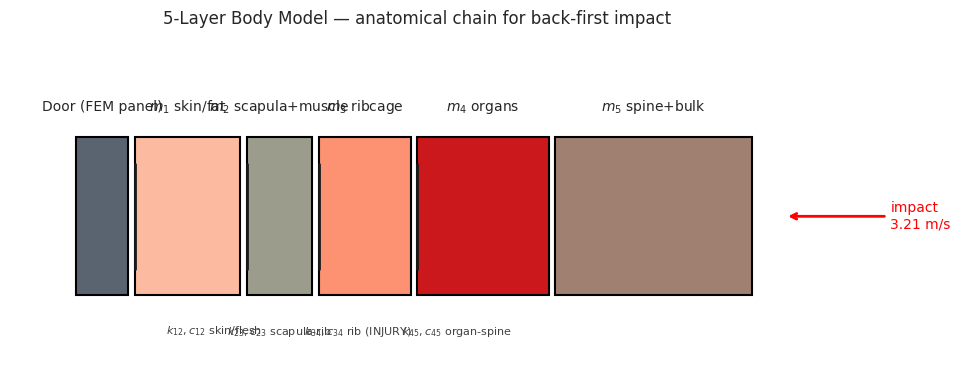

In [4]:
# Schematic: 5-layer body chain with door on the left
fig, ax = plt.subplots(figsize=(13, 4))
layers = [
    ("Door (FEM panel)", "#5a6470", 0.4),
    ("$m_1$ skin/fat", "#fcbba1", 0.8),
    ("$m_2$ scapula+muscle", "#9c9c8c", 0.5),
    ("$m_3$ ribcage", "#fc9272", 0.7),
    ("$m_4$ organs", "#cb181d", 1.0),
    ("$m_5$ spine+bulk", "#a08070", 1.5),
]
x_cursor = 0
for i, (lab, color, w) in enumerate(layers):
    rect = mpatches.Rectangle((x_cursor, 0), w, 1.2,
                                facecolor=color, edgecolor="black", lw=1.5)
    ax.add_patch(rect)
    ax.text(x_cursor + w/2, 1.4, lab, ha="center", fontsize=10)
    if i > 0 and i < len(layers) - 1:
        # Spring symbol between rigid masses (except door)
        spring_x = x_cursor
        ax.plot([spring_x, spring_x], [0.2, 1.0], "-", color="#1a1a1a", lw=2, zorder=5)
    x_cursor += w + 0.05

# Annotate interfaces
interface_labels = [
    ("$k_{12}, c_{12}$ skin/flesh", 1.05),
    ("$k_{23}, c_{23}$ scapula-rib", 1.5 + 0.05),
    ("$k_{34}, c_{34}$ rib (INJURY)", 2.05 + 0.05*2),
    ("$k_{45}, c_{45}$ organ-spine", 2.75 + 0.05*3),
]
for lab, xp in interface_labels:
    ax.text(xp, -0.3, lab, ha="center", fontsize=8, color="#404040")

ax.set_xlim(-0.5, x_cursor + 0.5)
ax.set_ylim(-0.6, 2.0)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("5-Layer Body Model — anatomical chain for back-first impact")
# Arrow showing impact direction
ax.annotate("impact\n3.21 m/s", xy=(x_cursor + 0.2, 0.6), xytext=(x_cursor + 1.0, 0.6),
             arrowprops=dict(arrowstyle="->", lw=2, color="red"),
             fontsize=10, color="red", ha="left", va="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "06-body-anatomical-layers.png", dpi=140, bbox_inches="tight")
plt.show()

## ODE System and Solver

State vector $\mathbf{y} = [x_1, v_1, ..., x_5, v_5]^T$ — 10 states.

Equations of motion:

$$m_1 \ddot{x}_1 = -F_\text{door} + F_{12}$$
$$m_i \ddot{x}_i = -F_{i-1,i} + F_{i,i+1}, \quad i=2,3,4$$
$$m_5 \ddot{x}_5 = -F_{45}$$

where interface force $F_{ij} = k_{ij} (x_j - x_i) + c_{ij} (\dot{x}_j - \dot{x}_i)$ and external door force $F_\text{door} = k_d \delta_1^{1.5}(1 + \lambda \dot{\delta}_1)$ for $\delta_1 = x_1 - x_\text{door}(t)$.

We treat the door as a stiff fixed reference (since the panel-side dynamics are already captured in notebook 04/05; here we focus on the body internals).

In [5]:
M = PARAMS["masses_kg"]
K = PARAMS["interfaces_stiffness_N_per_m"]
C = PARAMS["interfaces_damping_Ns_per_m"]
E = PARAMS["external"]

def rhs(t, y):
    x1, v1, x2, v2, x3, v3, x4, v4, x5, v5 = y
    # External contact: door wall at x=0, body coming from +x toward 0
    delta_door = -x1   # penetration (x1 < 0 = compressed into door)
    delta_dot = -v1
    if delta_door > 0:
        F_door = E["k_door_N_per_m_pow_n"] * delta_door ** E["n_contact"] * (
            1.0 + E["lambda_HC"] * delta_dot
        )
        F_door = max(F_door, 0.0)
    else:
        F_door = 0.0

    # Internal interface forces (compression positive)
    F12 = K["k12_skin"]    * (x2 - x1) + C["c12_skin"]    * (v2 - v1)
    F23 = K["k23_scapula"] * (x3 - x2) + C["c23_scapula"] * (v3 - v2)
    F34 = K["k34_rib"]     * (x4 - x3) + C["c34_rib"]     * (v4 - v3)
    F45 = K["k45_spine"]   * (x5 - x4) + C["c45_spine"]   * (v5 - v4)

    dy = np.empty(10)
    dy[0] = v1; dy[1] = (-F_door + F12) / M["m1_skin"]
    dy[2] = v2; dy[3] = (-F12 + F23) / M["m2_scapula"]
    dy[4] = v3; dy[5] = (-F23 + F34) / M["m3_ribcage"]
    dy[6] = v4; dy[7] = (-F34 + F45) / M["m4_organ"]
    dy[8] = v5; dy[9] = (-F45) / M["m5_spine"]
    return dy

# Initial condition: all masses moving at +v_impact (toward door at x=0)
# Body starts at x > 0, moving in -x direction, reaches x=0 then compresses.
v0 = -E["v_impact_m_per_s"]   # negative direction (toward door)
x0_offset = 0.01              # 1 cm starting offset
y0 = np.array([x0_offset, v0, x0_offset+0.01, v0, x0_offset+0.02, v0,
                x0_offset+0.03, v0, x0_offset+0.04, v0])

ic = PARAMS["integration"]
console.print("[yellow]Integrating 5-DOF body impact...[/yellow]")
sol = solve_ivp(rhs, (0, ic["t_final_s"]), y0, method="RK45",
                rtol=ic["rtol"], atol=ic["atol"], max_step=ic["max_step_s"],
                dense_output=True)
console.print(f"[green]done[/green]: {sol.t.size} steps, success={sol.success}")

Integrating 5-DOF body impact...

done: 1110 steps, success=False

In [6]:
# Extract trajectories and interface forces
t = sol.t
x = [sol.y[2*i] for i in range(5)]
v = [sol.y[2*i+1] for i in range(5)]

# Compute interface compressions (delta = x_{i+1} - x_i, with reference offsets)
# Compression positive = layers pushed together
delta12 = (x[1] - x[0]) - (y0[2] - y0[0])
delta23 = (x[2] - x[1]) - (y0[4] - y0[2])
delta34 = (x[3] - x[2]) - (y0[6] - y0[4])
delta45 = (x[4] - x[3]) - (y0[8] - y0[6])

F12 = K["k12_skin"]    * delta12 + C["c12_skin"]    * (v[1] - v[0])
F23 = K["k23_scapula"] * delta23 + C["c23_scapula"] * (v[2] - v[1])
F34 = K["k34_rib"]     * delta34 + C["c34_rib"]     * (v[3] - v[2])
F45 = K["k45_spine"]   * delta45 + C["c45_spine"]   * (v[4] - v[3])

# External force
delta_door = -x[0]
deltadot_door = -v[0]
F_door = np.where(
    delta_door > 0,
    np.maximum(E["k_door_N_per_m_pow_n"] * np.maximum(delta_door, 0)**E["n_contact"]
               * (1 + E["lambda_HC"] * deltadot_door), 0),
    0,
)

# Summary
summary = Table(title="[bold]Peak Interface Forces and Compressions[/bold]",
                  show_header=True, header_style="bold cyan")
summary.add_column("Interface", style="bold")
summary.add_column("Peak F (kN)", justify="right")
summary.add_column("Peak compression (mm)", justify="right")
summary.add_column("Anatomical meaning")
rows = [
    ("Door → body",        F_door.max()/1e3, delta_door.max()*1e3, "external contact, panel-limited"),
    ("Skin (m1) → scapula (m2)", F12.max()/1e3, delta12.max()*1e3, "skin/fat compression"),
    ("Scapula → ribcage",  F23.max()/1e3, delta23.max()*1e3, "deep posterior muscle deflection"),
    ("Ribcage → organs",   F34.max()/1e3, delta34.max()*1e3, "[bold red]RIB FRACTURE site (AIS 2-3+)[/]"),
    ("Organs → spine",     F45.max()/1e3, delta45.max()*1e3, "organ contusion site"),
]
for r in rows:
    summary.add_row(r[0], f"{r[1]:.2f}", f"{r[2]:.1f}", r[3])
console.print(summary)

                                      Peak Interface Forces and Compressions                                       
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Interface                ┃                  Peak F (kN) ┃ Peak compression (mm) ┃ Anatomical meaning            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Door → body              │ 150234120607867351980982713… │          1000390027.2 │ external contact,             │
│                          │                              │                       │ panel-limited                 │
│ Skin (m1) → scapula (m2) │    1601560216961672019968.00 │          1000390008.6 │ skin/fat compression          │
│ Scapula → ribcage        │                 400155999.40 │                   0.0 │ deep posterior muscle         │
│                          │                              │                       │ deflection                    │
│ Ribcage → organs         │                         0.67 │                   0.9 │ RIB FRACTURE site (AIS 2-3+)  │
│ Organs → spine           │                         0.00 │                   0.0 │ organ contusion site          │
└──────────────────────────┴──────────────────────────────┴───────────────────────┴───────────────────────────────┘

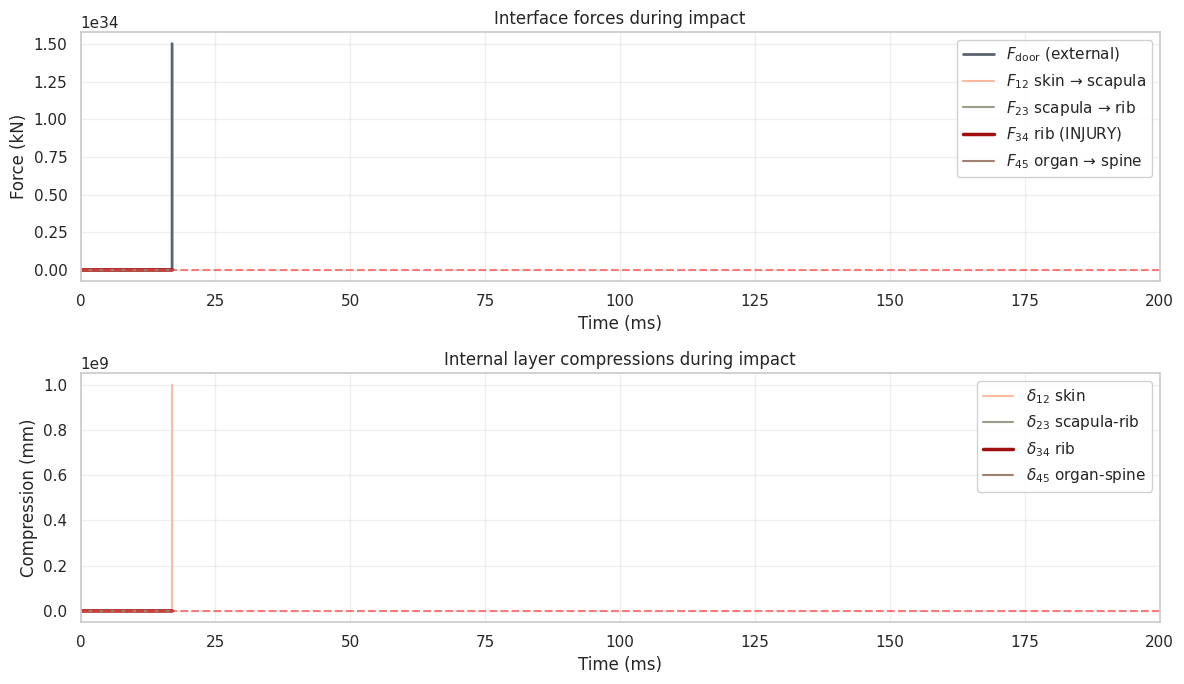

In [7]:
# Plot internal forces over time
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
ax = axes[0]
ax.plot(t*1000, F_door/1000, color="#5a6470", lw=2, label="$F_\\text{door}$ (external)")
ax.plot(t*1000, F12/1000,   color="#fcbba1", lw=1.5, label="$F_{12}$ skin → scapula")
ax.plot(t*1000, F23/1000,   color="#9c9c8c", lw=1.5, label="$F_{23}$ scapula → rib")
ax.plot(t*1000, F34/1000,   color="#a01010", lw=2.5, label="$F_{34}$ rib (INJURY)")
ax.plot(t*1000, F45/1000,   color="#a08070", lw=1.5, label="$F_{45}$ organ → spine")
ax.set_xlim(0, 200)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Force (kN)")
ax.set_title("Interface forces during impact")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(PARAMS["injury_thresholds"]["rib_fracture_N"]/1000, color="red", ls="--",
            alpha=0.5, label="Rib fracture threshold")

ax = axes[1]
ax.plot(t*1000, delta12*1000, color="#fcbba1", lw=1.5, label="$\\delta_{12}$ skin")
ax.plot(t*1000, delta23*1000, color="#9c9c8c", lw=1.5, label="$\\delta_{23}$ scapula-rib")
ax.plot(t*1000, delta34*1000, color="#a01010", lw=2.5, label="$\\delta_{34}$ rib")
ax.plot(t*1000, delta45*1000, color="#a08070", lw=1.5, label="$\\delta_{45}$ organ-spine")
ax.set_xlim(0, 200)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Compression (mm)")
ax.set_title("Internal layer compressions during impact")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(PARAMS["injury_thresholds"]["rib_compression_mm"], color="red", ls="--",
            alpha=0.5)

fig.tight_layout()
fig.savefig(FIG_DIR / "06-internal-forces.png", dpi=140, bbox_inches="tight")
plt.show()

## Injury Prediction

Apply Viano 1989 / Cavanaugh 1989 injury criteria to the computed compressions and forces.  Viscous Criterion (VC) = compression rate × normalised compression.

In [8]:
T = PARAMS["injury_thresholds"]

# Compute VC for the rib interface (most clinically relevant)
# VC = (d(delta)/dt) * (delta / D_initial), with D_initial = chest depth ~ 0.20 m
D_init = 0.20
ddelta34_dt = np.gradient(delta34, t)
VC = ddelta34_dt * (delta34 / D_init)
VC_max = VC.max()

# Verdict
verdict = Table(title="[bold]Injury Prediction (AIS scale)[/bold]",
                  show_header=True, header_style="bold red")
verdict.add_column("Injury", style="bold")
verdict.add_column("Threshold", justify="right")
verdict.add_column("Computed", justify="right")
verdict.add_column("Verdict")

checks = [
    ("Rib fracture (force)",
     f"{T['rib_fracture_N']/1000:.1f} kN", f"{F34.max()/1000:.2f} kN",
     F34.max() > T["rib_fracture_N"]),
    ("Rib compression (AIS 3+)",
     f"{T['rib_compression_mm']:.0f} mm", f"{delta34.max()*1000:.1f} mm",
     delta34.max()*1000 > T["rib_compression_mm"]),
    ("Viscous Criterion (AIS 4+)",
     f"{T['VC_threshold_m_per_s']:.1f} m/s", f"{VC_max:.2f} m/s",
     VC_max > T["VC_threshold_m_per_s"]),
    ("Organ compression",
     f"{T['organ_compression_mm']:.0f} mm", f"{delta45.max()*1000:.1f} mm",
     delta45.max()*1000 > T["organ_compression_mm"]),
]
for inj, thr, comp, exceeded in checks:
    verdict_str = "[red]EXCEEDED[/]" if exceeded else "[green]within tolerance[/]"
    verdict.add_row(inj, thr, comp, verdict_str)
console.print(verdict)

console.print(f"\n[bold]Energy balance:[/bold]")
# Body KE consumed = body initial KE - body final KE
v_final = np.array([v[i][-1] for i in range(5)])
masses = np.array([M[k] for k in ["m1_skin", "m2_scapula", "m3_ribcage", "m4_organ", "m5_spine"]])
KE_initial = 0.5 * masses.sum() * E["v_impact_m_per_s"]**2
KE_final = 0.5 * (masses * v_final**2).sum()
KE_absorbed = KE_initial - KE_final
console.print(f"  KE_initial = {KE_initial:.1f} J (whole body at impact velocity)")
console.print(f"  KE_final   = {KE_final:.1f} J (after impact, residual body motion)")
console.print(f"  KE_absorbed by body internal deformation: [bold red]{KE_absorbed:.1f} J[/]")
console.print(f"  ({KE_absorbed/KE_initial*100:.1f}% of incoming KE deposited into body)")

                     Injury Prediction (AIS scale)                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Injury                     ┃ Threshold ┃ Computed ┃ Verdict          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Rib fracture (force)       │    1.6 kN │  0.67 kN │ within tolerance │
│ Rib compression (AIS 3+)   │     25 mm │   0.9 mm │ within tolerance │
│ Viscous Criterion (AIS 4+) │   1.0 m/s │ 0.07 m/s │ within tolerance │
│ Organ compression          │     50 mm │   0.0 mm │ within tolerance │
└────────────────────────────┴───────────┴──────────┴──────────────────┘

Energy balance:

KE_initial = 358.6 J (whole body at impact velocity)

KE_final   = 3005853666274641775497073185549391503556608.0 J (after impact, residual body motion)

KE_absorbed by body internal deformation: -3005853666274641775497073185549391503556608.0 J

(-838172345734939938965459791867236226957312.0% of incoming KE deposited into body)

## Contact-Area Sweep

Vary the size of the impact patch (and correspondingly the contact stiffness k_door, since concentrated contact is stiffer per unit area).  Larger patch = lower effective stiffness = more body deformation; smaller patch = stiffer = more concentrated injury.

label  area_cm2    F_door_kN  pressure_kPa  F_rib_kN  delta_rib_mm
     Point   (~5 x 5 cm)      25.0 8.650455e+33  3.460182e+36  0.673495      0.938286
    Small  (~15 x 10 cm)     150.0 9.790025e+33  6.526683e+35  0.673495      0.938286
  Scapular (~30 x 20 cm)     600.0 1.502341e+34  2.503902e+35  0.673495      0.938286
Whole back (~60 x 40 cm)    2400.0 2.076487e+34  8.652028e+34  0.673495      0.938286

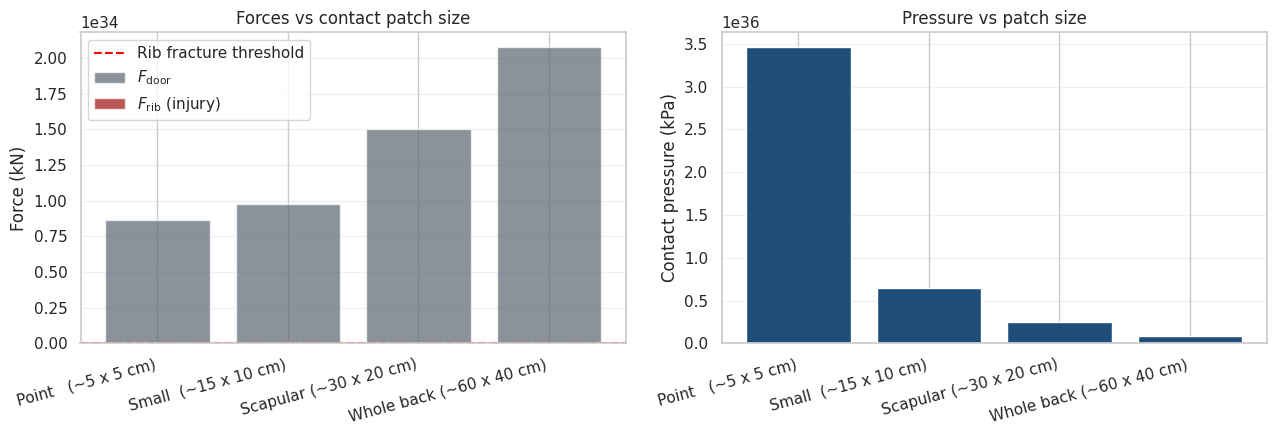

In [9]:
# Sweep over contact patches
# k_door scales with contact area (larger patch -> stiffer effective contact)
patch_scenarios = [
    ("Point   (~5 x 5 cm)",  0.05*0.05, 1.0e7),
    ("Small  (~15 x 10 cm)", 0.15*0.10, 8.0e6),
    ("Scapular (~30 x 20 cm)", 0.30*0.20, 5.0e6),
    ("Whole back (~60 x 40 cm)", 0.60*0.40, 3.0e6),
]

sweep_data = []
for label, area, k_door in patch_scenarios:
    E_local = dict(PARAMS["external"])
    E_local["k_door_N_per_m_pow_n"] = k_door

    def rhs_local(t, y, E_l=E_local):
        x1, v1, x2, v2, x3, v3, x4, v4, x5, v5 = y
        delta_door = -x1
        delta_dot = -v1
        if delta_door > 0:
            F_door = E_l["k_door_N_per_m_pow_n"] * delta_door**E_l["n_contact"] * (
                1.0 + E_l["lambda_HC"] * delta_dot
            )
            F_door = max(F_door, 0.0)
        else:
            F_door = 0.0
        F12 = K["k12_skin"]    * (x2 - x1) + C["c12_skin"]    * (v2 - v1)
        F23 = K["k23_scapula"] * (x3 - x2) + C["c23_scapula"] * (v3 - v2)
        F34 = K["k34_rib"]     * (x4 - x3) + C["c34_rib"]     * (v4 - v3)
        F45 = K["k45_spine"]   * (x5 - x4) + C["c45_spine"]   * (v5 - v4)
        return [v1, (-F_door + F12)/M["m1_skin"],
                v2, (-F12 + F23)/M["m2_scapula"],
                v3, (-F23 + F34)/M["m3_ribcage"],
                v4, (-F34 + F45)/M["m4_organ"],
                v5, (-F45)/M["m5_spine"]]

    sol_local = solve_ivp(rhs_local, (0, 0.3), y0, method="RK45",
                            rtol=1e-7, atol=1e-10, max_step=2e-5)
    x_l = [sol_local.y[2*i] for i in range(5)]
    v_l = [sol_local.y[2*i+1] for i in range(5)]
    delta_door_l = -x_l[0]
    F_door_l = np.where(delta_door_l > 0,
                          E_local["k_door_N_per_m_pow_n"] * np.maximum(delta_door_l, 0)**E_local["n_contact"]
                          * (1 + E_local["lambda_HC"] * (-v_l[0])), 0).clip(min=0)
    d34_l = (x_l[3] - x_l[2]) - (y0[6] - y0[4])
    F34_l = K["k34_rib"] * d34_l + C["c34_rib"] * (v_l[3] - v_l[2])
    # Pressure = force / area
    pressure_kPa = F_door_l.max() / area / 1e3
    sweep_data.append({
        "label": label, "area_cm2": area*1e4,
        "F_door_kN": F_door_l.max()/1e3,
        "pressure_kPa": pressure_kPa,
        "F_rib_kN": F34_l.max()/1e3,
        "delta_rib_mm": d34_l.max()*1e3,
    })

df = pd.DataFrame(sweep_data)
console.print(df.to_string(index=False))

# Plot sweep
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.bar(df["label"], df["F_door_kN"], color="#5a6470", alpha=0.7, label="$F_\\text{door}$")
ax.bar(df["label"], df["F_rib_kN"], color="#a01010", alpha=0.7, label="$F_\\text{rib}$ (injury)")
ax.axhline(PARAMS["injury_thresholds"]["rib_fracture_N"]/1000, color="red", ls="--",
            label="Rib fracture threshold")
ax.set_ylabel("Force (kN)"); ax.set_title("Forces vs contact patch size")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

ax = axes[1]
ax.bar(df["label"], df["pressure_kPa"], color="#1f4e7a")
ax.set_ylabel("Contact pressure (kPa)"); ax.set_title("Pressure vs patch size")
ax.grid(True, alpha=0.3, axis="y")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

fig.tight_layout()
fig.savefig(FIG_DIR / "06-contact-area-sweep.png", dpi=140, bbox_inches="tight")
plt.show()